# Results analysis
This notebook contains the most relevant analysis, extracted from a large set of data exploration conducted in the past few months. The goal is to reduce the analysis to the minimum number of plots necessary to support the claims made in this project i.e., that a branch and bound algorithm enhanced with profiling outperforms its standard counterpart.

**Table of Contents**

[Functions definition and environment setup](#functions-definition-and-environment-setup)  
[Data analysis](#data-analysis)  
├── [Epsilon ε=0.1 with max nodes 2000](#epsilon-varepsilon01-with-max-nodes-2000)  
├── [Epsilon ε=0.05 with max nodes 2000](#epsilon-varepsilon005-with-max-nodes-2000)  
└── [Epsilon ε=0.01 with max nodes 2000](#epsilon-varepsilon001-with-max-nodes-2000)

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Functions definition and environment setup

In [42]:
df_results, epsilon, approximation, max_nodes, n_seeds = None, None, None, None, None

In [43]:
def load_data_and_config(filename, epsilon_value, max_nodes_value):
  """Load experimental results and configuration parameters."""
  global df_results, epsilon, approximation, max_nodes, n_seeds
  folder_path_output = "output"
  
  epsilon = epsilon_value
  approximation = 2 * epsilon
  max_nodes = max_nodes_value
  n_seeds = 200
  
  df_results = pd.read_csv(f"{folder_path_output}/{filename}")

In [44]:
def initialize_plot_data():
  """Initialize variables needed for plotting."""
  global unique_pairs, n_pairs, profiling_modes
  
  # Get unique combinations of (n_jobs, n_machines)
  unique_pairs = df_results[['n_jobs', 'n_machines']].drop_duplicates().reset_index(drop=True)
  n_pairs = len(unique_pairs)
  
  # Define profiling modes
  profiling_modes = ['NO_PROFILING', 'PRUNE']

In [45]:
def plot_histogram_mirrored(column_name: str):
  """
  Plot histograms for each (n_jobs, n_machines) pair with both profiling modes on the same plot.
  NO_PROFILING bars go upward, PRUNE bars are mirrored below the x-axis.
  """
  # Calculate grid size (n_pairs rows, 1 column)
  fig, axes = plt.subplots(n_pairs, 1, figsize=(12, 3 * n_pairs), sharex=False)
  if n_pairs == 1:
    axes = [axes]

  # Calculate the number of instances (excluding the header row if needed)
  n_instances = n_seeds
  fig.suptitle(f'{n_instances} instances using $\\mathbf{{\\varepsilon={epsilon}}}$', 
         fontsize=14, fontweight='bold', y=1.02)

  colors_dict = {'NO_PROFILING': 'C0', 'PRUNE': 'C1'}

  for row_idx, (_, pair_row) in enumerate(unique_pairs.iterrows()):
    n_j = pair_row['n_jobs']
    n_m = pair_row['n_machines']
    
    ax = axes[row_idx]
    
    # Get data for both profiling modes
    df_no_profiling = df_results[(df_results['n_jobs'] == n_j) & 
                                   (df_results['n_machines'] == n_m) & 
                                   (df_results['profiling_mode'] == 'NO_PROFILING')]
    
    df_prune = df_results[(df_results['n_jobs'] == n_j) & 
                          (df_results['n_machines'] == n_m) & 
                          (df_results['profiling_mode'] == 'PRUNE')]
    
    # Sort both by column_name in descending order
    df_no_profiling_sorted = df_no_profiling.sort_values(column_name, ascending=False).reset_index(drop=True)
    df_prune_sorted = df_prune.sort_values(column_name, ascending=False).reset_index(drop=True)
    
    # Ensure both have the same number of instances (use the longer one)
    max_len = max(len(df_no_profiling_sorted), len(df_prune_sorted))
    x_positions = np.arange(max_len)
    
    # Get values (pad with zeros if needed)
    values_no_profiling = np.pad(df_no_profiling_sorted[column_name].values, 
                                  (0, max_len - len(df_no_profiling_sorted)), 
                                  constant_values=0)
    values_prune = np.pad(df_prune_sorted[column_name].values, 
                          (0, max_len - len(df_prune_sorted)), 
                          constant_values=0)
    
    # Plot NO_PROFILING upward
    ax.bar(x_positions, values_no_profiling, width=1.0, color=colors_dict['NO_PROFILING'], 
         edgecolor='k', alpha=0.8, label='NO_PROFILING', linewidth=0.5)
    
    # Plot PRUNE mirrored (downward) - use negative values
    ax.bar(x_positions, -values_prune, width=1.0, color=colors_dict['PRUNE'], 
           edgecolor='k', alpha=0.8, label='PRUNE', linewidth=0.5)
    
    # Add horizontal lines for max_nodes
    ax.axhline(max_nodes, color='red', linestyle='--', linewidth=1.5, 
               label=f'max nodes = {max_nodes}', zorder=0, alpha=0.7)
    ax.axhline(-max_nodes, color='red', linestyle='--', linewidth=1.5, 
               zorder=0, alpha=0.7)
    
    # Add a line at y=0 for clarity
    ax.axhline(0, color='black', linestyle='-', linewidth=0.8, zorder=1)
    
    # Format y-axis to show absolute values (fix warning by setting ticks first)
    yticks = ax.get_yticks()
    ax.set_yticks(yticks)
    ax.set_yticklabels([f'{abs(int(y))}' for y in yticks])
    
    # Remove gaps on x-axis (only if max_len > 1 to avoid warning)
    if max_len > 1:
      ax.set_xlim(-0.5, max_len - 0.5)
    
    # Set x-axis ticks and labels for all subplots
    step = max(1, len(x_positions)//10)
    ax.set_xticks(x_positions[::step])
    ax.set_xticklabels(range(0, max_len, step), 
                       rotation=45, ha='right', fontsize=9)
    
    # Only show x-axis label on the last subplot, hide tick labels on others
    if row_idx == n_pairs - 1:
      ax.set_xlabel(f'Instances (sorted by {column_name})', fontsize=10)
      ax.tick_params(labelbottom=True, pad=-2)
    else:
      ax.set_xlabel('')
      ax.tick_params(labelbottom=False)
    
    ax.set_ylabel(str(column_name).replace('_', ' '), fontsize=10)
    
    # Add title inside the subplot (top-left corner) with bold font
    ax.text(0.4, 0.97, f'n_jobs={n_j}, n_machines={n_m}', 
            transform=ax.transAxes, fontsize=11, fontweight='bold',
            verticalalignment='top', horizontalalignment='left',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.grid(axis='y', alpha=0.3)

  # Add a single legend at the top, outside the subplots, in a horizontal row
  handles, labels = axes[0].get_legend_handles_labels()
  fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.01), 
             ncol=3, fontsize=10, frameon=True)
  
  plt.tight_layout()
  plt.savefig(f'docs/sections/7. analisi/histogram_mirrored_{column_name}_e{epsilon.__str__().replace('.', '-')}.png', dpi=300)
  plt.show()

## Data analysis

### Epsilon $\varepsilon=0.1$ with max nodes $2000$

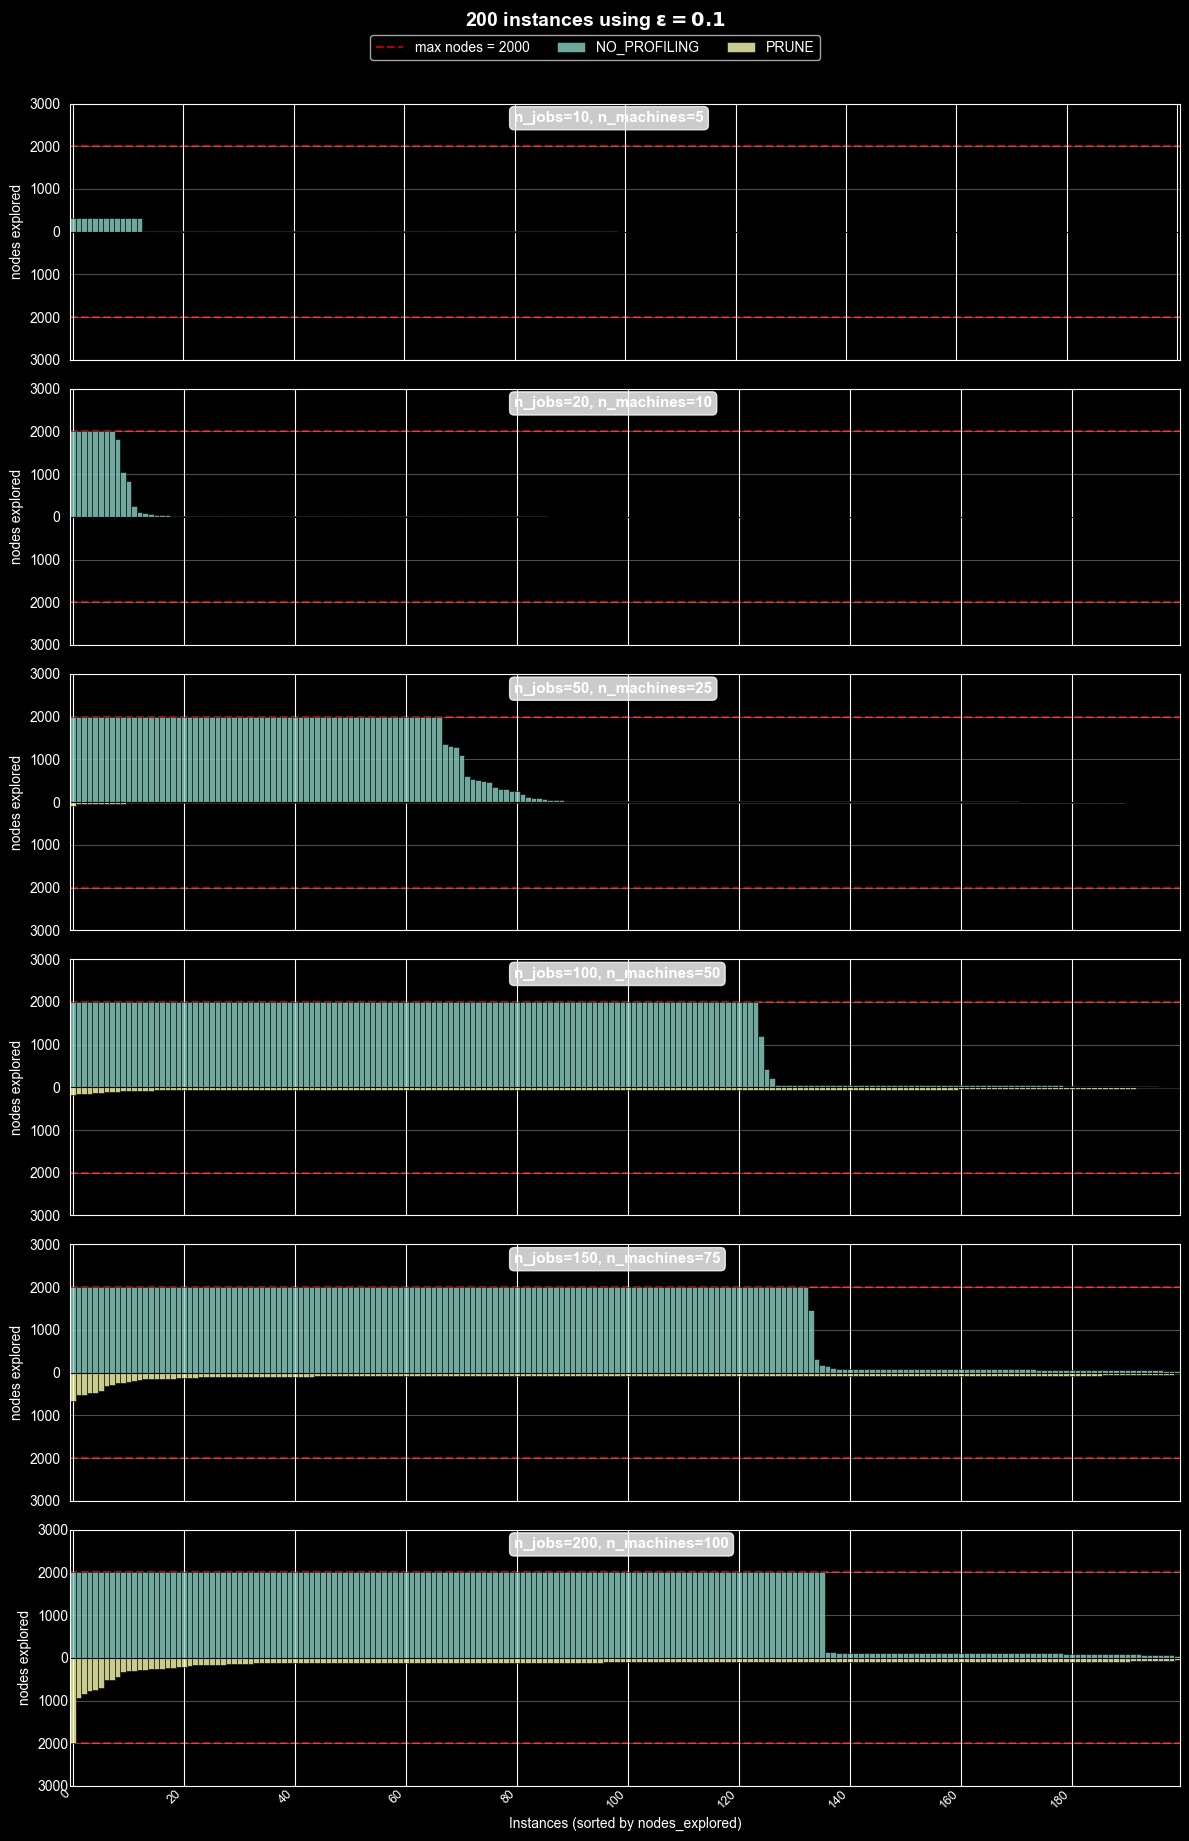

In [46]:
load_data_and_config(filename="results-e0.1.csv", epsilon_value=0.1, max_nodes_value=2_000)
initialize_plot_data()
plot_histogram_mirrored('nodes_explored')

### Epsilon $\varepsilon=0.05$ with max nodes $2000$

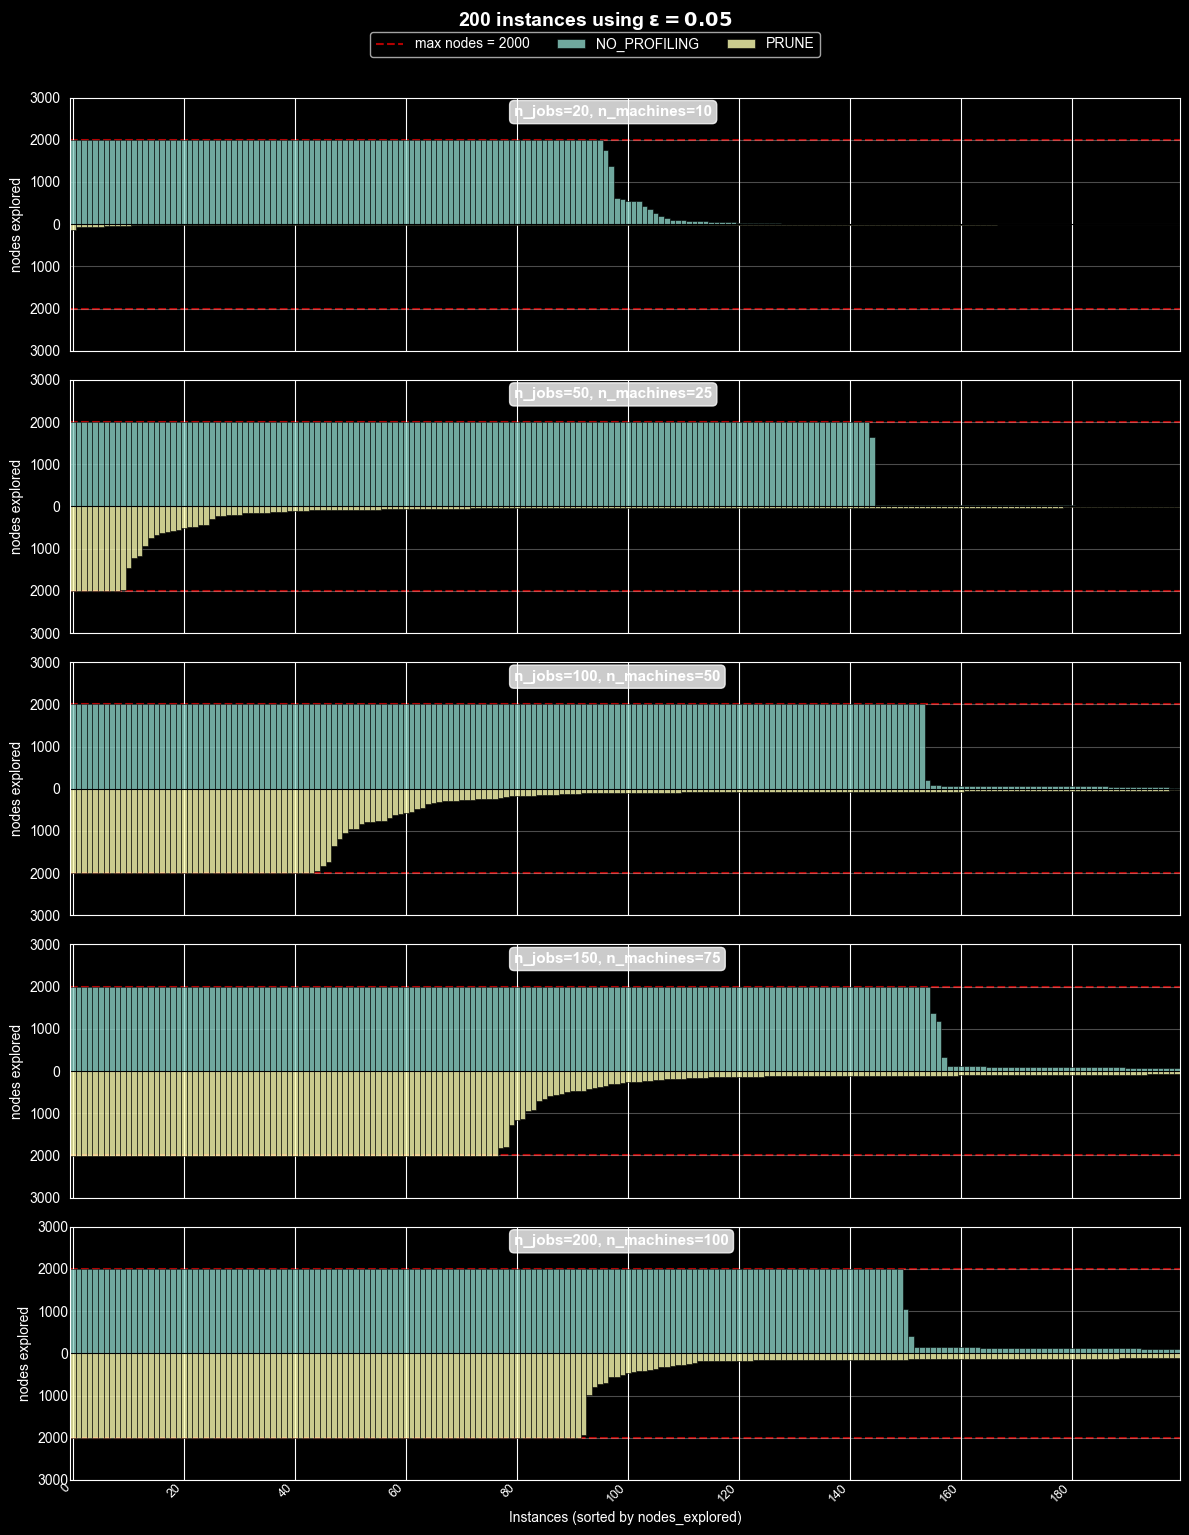

In [47]:
load_data_and_config(filename="results-e0.05.csv", epsilon_value=0.05, max_nodes_value=2_000)
initialize_plot_data()
plot_histogram_mirrored('nodes_explored')

### Epsilon $\varepsilon=0.01$ with max nodes $2000$

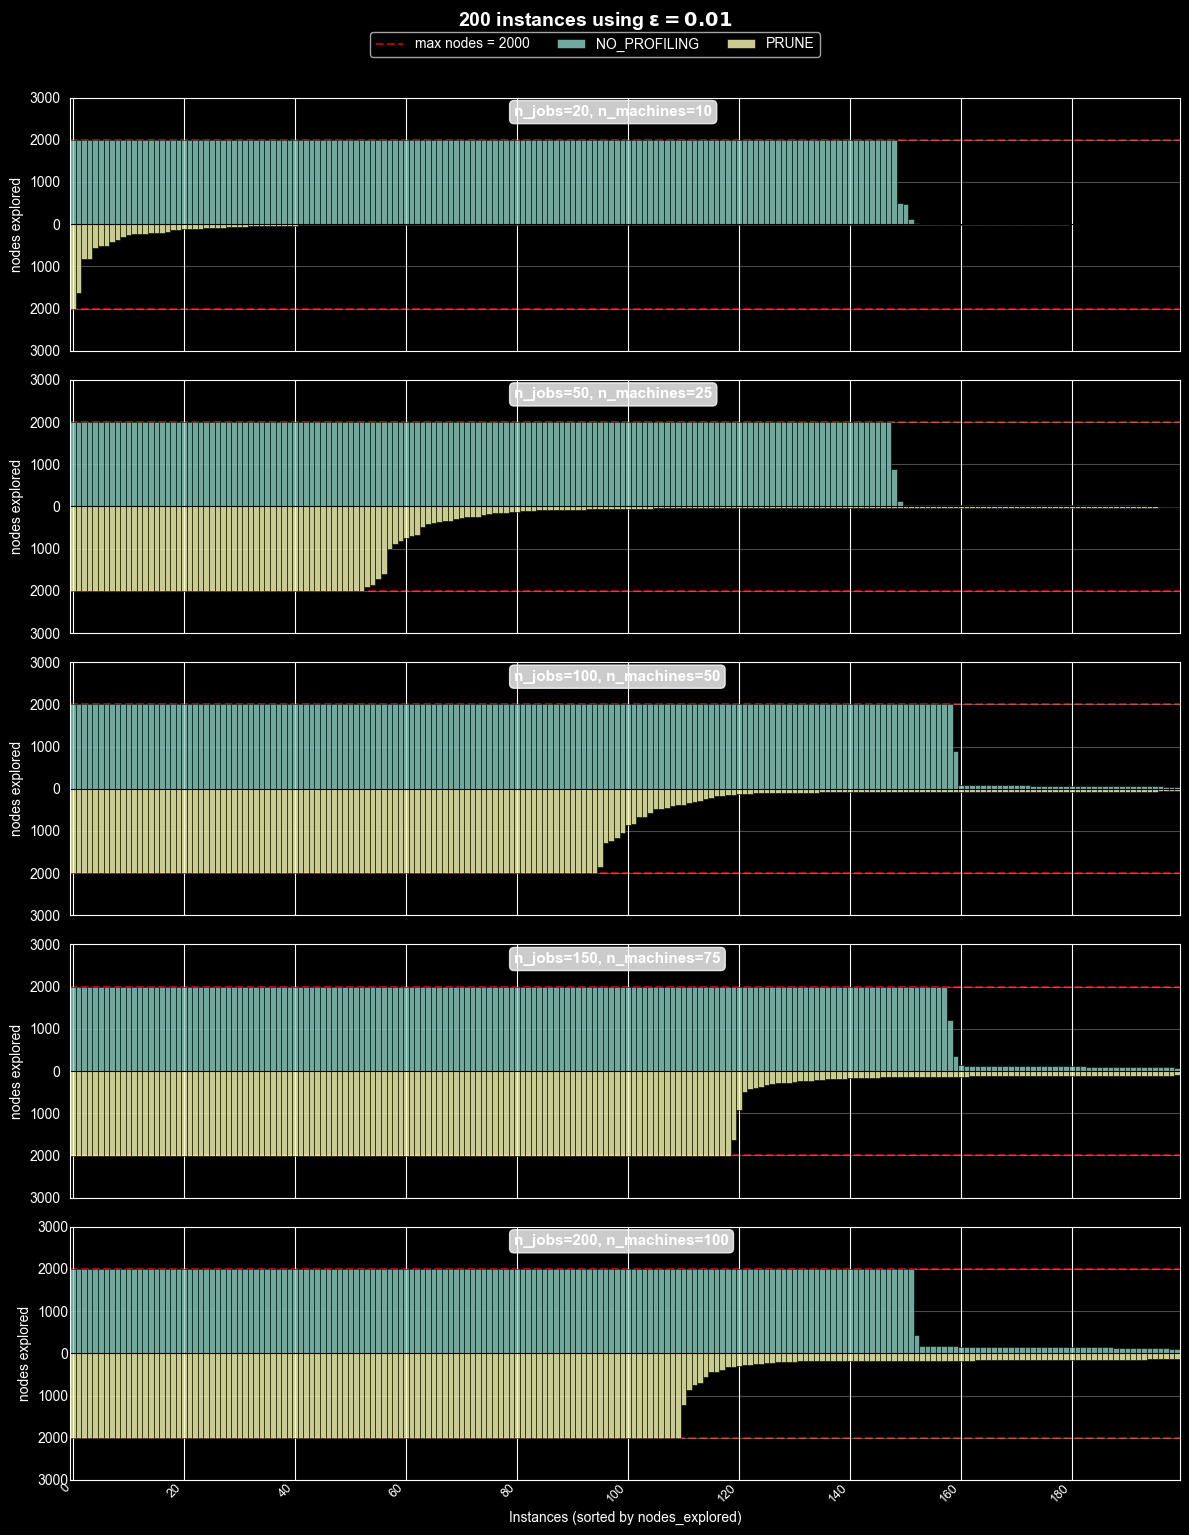

In [48]:
load_data_and_config(filename="results-e0.01.csv", epsilon_value=0.01, max_nodes_value=2_000)
initialize_plot_data()
plot_histogram_mirrored('nodes_explored')